In [1]:
import pandas as pd
import re

# Load the CSV file
file_path = 'data/Raw data.csv'
data = pd.read_csv(file_path)

useless_cols = ['Response ID (ResponseId)','Recorded Date (RecordedDate)']
data.drop(columns=useless_cols, inplace=True)

data.head()

,Progress (Progress),Duration (in seconds) (Duration (in seconds)),Finished (Finished),How long have you been working at your present office? (background_time),"In a typical week, how many hours do you spend in your workspace? (background_hours)",How would you describe the work that you do? - Selected Choice (background_work),How would you describe the work that you do? - Other - Text (background_work_5_TEXT),What is your age? (background_age),What is your gender? (background_gender),"How satisfied are you with the air quality (i.e., stuffy/ stale air, cleanliness, odors) in your workspace? - How satisfied are you with the air quality (i.e., stuffy/ stale air, cleanliness, odors) in your workspace? (iaq_sat_1)",...,Think about your life in general. \n\n\nBelow are six statements with which you may agree or disagree. Indicate the degree to which you agree or disagree with the following statements. Please be open and honest in your responses. - I feel as though my life has purpose (support_life_6),Think about your job.\n\n \n\nIndicate the degree to which you agree or disagree with the following statements. Please be open and honest in your responses. - I am satisfied with my job (support_job_1),Think about your job.\n\n \n\nIndicate the degree to which you agree or disagree with the following statements. Please be open and honest in your responses. - I feel as though my job gives me a sense of purpose (support_job_2),Think about your job.\n\n \n\nIndicate the degree to which you agree or disagree with the following statements. Please be open and honest in your responses. - I feel as though I am competent at my job (support_job_3),Think about your job.\n\n \n\nIndicate the degree to which you agree or disagree with the following statements. Please be open and honest in your responses. - I feel satisfied with my current work-life balance (support_job_4),Think about your job.\n\n \n\nIndicate the degree to which you agree or disagree with the following statements. Please be open and honest in your responses. - I plan to stay at my job for as long as I can (support_job_5),"Overall, do you feel your office environment enhances or interferes with your ability to get your job done? - Overall, do you feel your office environment enhances or interferes with your ability to get your job done? (general_enhance_1)","All things considered, how satisfied are you with your personal workspace? - All things considered, how satisfied are you with your personal workspace? (general_sat_space_1)",How satisfied are you with the office overall? (general_sat_building_1),Any additional comments or recommendations about your personal workspace or building overall? (general_other_text)
0,100,662,True,More than 3 years,11-20,Staff,NaN,10.0,Female,Dissatisfied,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100,434,True,More than 3 years,More than 50,Executive,NaN,56.0,Female,Satisfied,...,Strongly agree,Strongly agree,Strongly agree,Slightly agree,Neither agree nor disagree,Disagree,Enhances,Satisfied,Satisfied,Long survey
2,100,523,True,3-6 months,11-20,Staff,NaN,30.0,Male,Very satisfied,...,Neither agree nor disagree,Agree,Slightly disagree,Neither agree nor disagree,Agree,Slightly agree,Enhances,Satisfied,Satisfied,NaN
3,100,466,True,2-3 years,41-50,Management,NaN,25.0,Female,Somewhat satisfied,...,Neither agree nor disagree,Slightly disagree,Slightly disagree,Agree,Slightly agree,Agree,Neither enhances nor interferes,Neither satisfied nor dissatisfied,Satisfied,NaN
4,100,786,True,More than 3 years,10 or less,Executive,NaN,56.0,Male,Very satisfied,...,Strongly agree,Agree,Strongly agree,Strongly agree,Slightly agree,Strongly agree,Enhances,Satisfied,Very satisfied,NaN


In [2]:
data.columns

Index(['Progress (Progress)', 'Duration (in seconds) (Duration (in seconds))',
       'Finished (Finished)',
       'How long have you been working at your present office? (background_time)',
       'In a typical week, how many hours do you spend in your workspace? (background_hours)',
       'How would you describe the work that you do? - Selected Choice (background_work)',
       'How would you describe the work that you do? - Other - Text (background_work_5_TEXT)',
       'What is your age? (background_age)',
       'What is your gender? (background_gender)',
       'How satisfied are you with the air quality (i.e., stuffy/ stale air, cleanliness, odors) in your workspace? - How satisfied are you with the air quality (i.e., stuffy/ stale air, cleanliness, odors) in your workspace? (iaq_sat_1)',
       ...
       'Think about your life in general. \n\n\nBelow are six statements with which you may agree or disagree. Indicate the degree to which you agree or disagree with the following

In [3]:
# preprocessing the columns name
def extract_column_name(column_name):
    # Using regex to find the content inside the last set of parentheses
    match = re.search(r'\(([^)]+)\)$', column_name)
    return match.group(1) if match else column_name

column_names = data.columns
# Applying the function to each column name
extracted_column_names = [extract_column_name(name) for name in column_names]
data.columns = extracted_column_names
data

,Progress,Duration (in seconds) (Duration (in seconds)),Finished,background_time,background_hours,background_work,background_work_5_TEXT,background_age,background_gender,iaq_sat_1,...,support_life_6,support_job_1,support_job_2,support_job_3,support_job_4,support_job_5,general_enhance_1,general_sat_space_1,general_sat_building_1,general_other_text
0,100,662,True,More than 3 years,11-20,Staff,NaN,10.0,Female,Dissatisfied,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100,434,True,More than 3 years,More than 50,Executive,NaN,56.0,Female,Satisfied,...,Strongly agree,Strongly agree,Strongly agree,Slightly agree,Neither agree nor disagree,Disagree,Enhances,Satisfied,Satisfied,Long survey
2,100,523,True,3-6 months,11-20,Staff,NaN,30.0,Male,Very satisfied,...,Neither agree nor disagree,Agree,Slightly disagree,Neither agree nor disagree,Agree,Slightly agree,Enhances,Satisfied,Satisfied,NaN
3,100,466,True,2-3 years,41-50,Management,NaN,25.0,Female,Somewhat satisfied,...,Neither agree nor disagree,Slightly disagree,Slightly disagree,Agree,Slightly agree,Agree,Neither enhances nor interferes,Neither satisfied nor dissatisfied,Satisfied,NaN
4,100,786,True,More than 3 years,10 or less,Executive,NaN,56.0,Male,Very satisfied,...,Strongly agree,Agree,Strongly agree,Strongly agree,Slightly agree,Strongly agree,Enhances,Satisfied,Very satisfied,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,1,24,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,9,71,False,More than 3 years,10 or less,Staff,NaN,45.0,Female,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,6,66,False,More than 3 years,11-20,Administrative support,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,1,1021,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
dictionary = {
 'Finished': {True: 1, False: 0},
 'background_time': {'Less than 3 months': 0, '3-6 months': 1, '7-12 months': 2, '1-2 years': 3, '2-3 years': 4, 'More than 3 years': 5},

 'background_hours': {'10 or less': 0, '11-20': 1, '21-30': 2, '31-40': 3, '41-50': 4 ,'More than 50': 5}, 

 'background_work': {'Staff': 5,  'Executive': 2,  'Management': 3,  'Other': 4,  'Administrative support': 0,  'C-level executive': 1},

 'background_gender': {'Female': 0, 'Male': 1},

 'iaq_sat_1': { 'Very dissatisfied': 5, 'Somewhat dissatisfied': 3, 'Dissatisfied': 0,  'Satisfied': 2,  'Very satisfied': 6,  'Somewhat satisfied': 4,  'Neither satisfied nor dissatisfied': 1,  }, 

 'iaq_dis_level_1': {'Not a problem': 0,  'Minor problem': 1,  'A problem': 2,  'Major problem': 3}, 
 'iaq_dis_level_2': {'Not a problem': 0,  'Minor problem': 1,  'A problem': 2,  'Major problem': 3}, 
 'iaq_dis_level_3': {'Not a problem': 0,  'Minor problem': 1,  'A problem': 2,  'Major problem': 3}, 

 'thermal_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6}, 
 'thermal_sat_2': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},


 'thermal_weather_hot': {'Be cooler': 0, 'Not change': 1, 'Be warmer': 2},
 'thermal_weather_cold': {'Be cooler': 2, 'Not change': 1, 'Be warmer': 0},


 'light_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'light_sat_2': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'light_sat_3': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'light_sat_4': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'light_task': {'Yes': 2, 'Not sure': 1, 'No': 0},

 'acoustic_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'acoustic_sat_2': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},


 'furnish_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'furnish_sat_2': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'furnish_sat_3': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},



 'layout_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'layout_sat_2': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'layout_sat_3': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},


 'clean_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'clean_sat_2': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},

 'amenities_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'amenities_sat_2': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'amenities_sat_3': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'amenities_sat_4': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'amenities_sat_5': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},


 'location_near_1': {'No': 0, 'Yes': 1},
 'location_near_2': {'Yes': 1, 'No': 0},


 'amenities_prox_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Not applicable': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'amenities_prox_sat_2': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Not applicable': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'amenities_prox_sat_3': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Not applicable': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'amenities_prox_sat_4': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Not applicable': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'amenities_prox_sat_5': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Not applicable': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},


 'water_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'water_sat_2': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'water_dis_water': {'I dislike the taste': 0, 'Other': 1},
 'nutrition_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},

 'wellness_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'My workplace does not have this policy': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'wellness_sat_2': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'My workplace does not have this policy': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'wellness_sat_3': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'My workplace does not have this policy': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'wellness_sat_4': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'My workplace does not have this policy': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'wellness_sat_5': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'My workplace does not have this policy': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'wellness_sat_6': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'My workplace does not have this policy': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},


 'health_rate_1': {'Extremely healthy': 0,  'Healthy': 1,  'Neither healthy nor unhealthy': 2,  'Unhealthy': 3,  'Extremely unhealthy': 4},
 'health_rate_2': {'Extremely healthy': 0,  'Healthy': 1,  'Neither healthy nor unhealthy': 2,  'Unhealthy': 3,  'Extremely unhealthy': 4},
 'health_mental_1': {'Extremely healthy': 0,  'Healthy': 1,  'Neither healthy nor unhealthy': 2,  'Unhealthy': 3,  'Extremely unhealthy': 4},
 'health_mental_2': {'Extremely healthy': 0,  'Healthy': 1,  'Neither healthy nor unhealthy': 2,  'Unhealthy': 3,  'Extremely unhealthy': 4},

 'health_interfere_1': {'Significantly enhances': 0,  'Enhances': 1,  'Somewhat enhances': 2,  'Neither enhances nor interferes': 3,  'Somewhat interferes': 4,  'Interferes': 5},
 'health_interfere_2': {'Significantly enhances': 0,  'Enhances': 1,  'Somewhat enhances': 2,  'Neither enhances nor interferes': 3,  'Somewhat interferes': 4,  'Interferes': 5},
 'health_interfere_3': {'Significantly enhances': 0,  'Enhances': 1,  'Somewhat enhances': 2,  'Neither enhances nor interferes': 3,  'Somewhat interferes': 4,  'Interferes': 5},
 'health_interfere_4': {'Significantly enhances': 0,  'Enhances': 1,  'Somewhat enhances': 2,  'Neither enhances nor interferes': 3,  'Somewhat interferes': 4,  'Interferes': 5},


 'activity_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},

 'support_sat_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'support_sat_2': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'support_sat_3': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},

 'support_life_1': {'Strongly agree': 0,  'Agree': 1,  'Slightly agree': 2, 'Neither agree nor disagree': 3, 'Slightly disagree': 4, 'Disagree': 5, 'Strongly disagree': 6},
 'support_life_2': {'Strongly agree': 0,  'Agree': 1,  'Slightly agree': 2, 'Neither agree nor disagree': 3, 'Slightly disagree': 4, 'Disagree': 5, 'Strongly disagree': 6},
 'support_life_3': {'Strongly agree': 0,  'Agree': 1,  'Slightly agree': 2, 'Neither agree nor disagree': 3, 'Slightly disagree': 4, 'Disagree': 5, 'Strongly disagree': 6},
 'support_life_4': {'Strongly agree': 0,  'Agree': 1,  'Slightly agree': 2, 'Neither agree nor disagree': 3, 'Slightly disagree': 4, 'Disagree': 5, 'Strongly disagree': 6},
 'support_life_5': {'Strongly agree': 0,  'Agree': 1,  'Slightly agree': 2, 'Neither agree nor disagree': 3, 'Slightly disagree': 4, 'Disagree': 5, 'Strongly disagree': 6},
 'support_life_6': {'Strongly agree': 0,  'Agree': 1,  'Slightly agree': 2, 'Neither agree nor disagree': 3, 'Slightly disagree': 4, 'Disagree': 5, 'Strongly disagree': 6},
 'support_job_1': {'Strongly agree': 0,  'Agree': 1,  'Slightly agree': 2, 'Neither agree nor disagree': 3, 'Slightly disagree': 4, 'Disagree': 5, 'Strongly disagree': 6},
 'support_job_2': {'Strongly agree': 0,  'Agree': 1,  'Slightly agree': 2, 'Neither agree nor disagree': 3, 'Slightly disagree': 4, 'Disagree': 5, 'Strongly disagree': 6},
 'support_job_3': {'Strongly agree': 0,  'Agree': 1,  'Slightly agree': 2, 'Neither agree nor disagree': 3, 'Slightly disagree': 4, 'Disagree': 5, 'Strongly disagree': 6},
 'support_job_4': {'Strongly agree': 0,  'Agree': 1,  'Slightly agree': 2, 'Neither agree nor disagree': 3, 'Slightly disagree': 4, 'Disagree': 5, 'Strongly disagree': 6},
 'support_job_5': {'Strongly agree': 0,  'Agree': 1,  'Slightly agree': 2, 'Neither agree nor disagree': 3, 'Slightly disagree': 4, 'Disagree': 5, 'Strongly disagree': 6},
 'general_enhance_1': {'Significantly enhances': 0,  'Enhances': 1,  'Somewhat enhances': 2,  'Neither enhances nor interferes': 3,  'Somewhat interferes': 4,  'Interferes': 5},

 'general_sat_space_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6},
 'general_sat_building_1': {'Very dissatisfied': 0, 'Dissatisfied': 1,  'Somewhat dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4, 'Satisfied': 5, 'Very satisfied': 6}
}

In [5]:
# Applying the encoding to the dataframe
for col, mapping in dictionary.items():
    data[col] = data[col].map(mapping)
#     new_data[col] = new_data[col].astype(pd.Int32Dtype())

# new_data = new_data.astype(int)
data

,Progress,Duration (in seconds) (Duration (in seconds)),Finished,background_time,background_hours,background_work,background_work_5_TEXT,background_age,background_gender,iaq_sat_1,...,support_life_6,support_job_1,support_job_2,support_job_3,support_job_4,support_job_5,general_enhance_1,general_sat_space_1,general_sat_building_1,general_other_text
0,100,662,1,5.0,1.0,5.0,NaN,10.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100,434,1,5.0,5.0,2.0,NaN,56.0,0.0,2.0,...,0.0,0.0,0.0,2.0,3.0,5.0,1.0,5.0,5.0,Long survey
2,100,523,1,1.0,1.0,5.0,NaN,30.0,1.0,6.0,...,3.0,1.0,4.0,3.0,1.0,2.0,1.0,5.0,5.0,NaN
3,100,466,1,4.0,4.0,3.0,NaN,25.0,0.0,4.0,...,3.0,4.0,4.0,1.0,2.0,1.0,3.0,3.0,5.0,NaN
4,100,786,1,5.0,0.0,2.0,NaN,56.0,1.0,6.0,...,0.0,1.0,0.0,0.0,2.0,0.0,1.0,5.0,6.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,1,24,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,9,71,0,5.0,0.0,5.0,NaN,45.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,6,66,0,5.0,1.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,1,1021,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Adjusting the approach to skip columns with all NaN values
from sklearn.preprocessing import OrdinalEncoder
# Creating a dictionary to hold encoding for each categorical column
encoding_dict = {}

# Using OrdinalEncoder from sklearn to encode the categorical values
ordinal_encoder = OrdinalEncoder()

for col in data.columns:
    # Selecting non-null data for encoding
    non_null_data = data[col][data[col].notnull()].unique()
    if non_null_data.size > 0:
        non_null_data = non_null_data.reshape(-1, 1)

        # Fitting the encoder and transforming the data to get the encoding
        encoded_data = ordinal_encoder.fit_transform(non_null_data)

        # Mapping the original values to the encoded numbers
        col_encoding = {value: int(encoded) for value, encoded in zip(non_null_data.flatten(), encoded_data.flatten())}

        # Adding the mapping to the dictionary
        encoding_dict[col] = col_encoding

# # Showing the encoding dictionary for the first few columns
# {col: encoding_dict[col] for col in list(encoding_dict)[:5]}  # Displaying a subset for brevity


In [7]:
new_data = pd.DataFrame()
# Applying the encoding to the dataframe
for col, mapping in encoding_dict.items():
    new_data[col] = data[col].map(mapping)
#     new_data[col] = new_data[col].astype(pd.Int32Dtype())

# new_data = new_data.astype(int)
new_data

C:\Users\Chan\AppData\Local\Temp\ipykernel_285076\3263825144.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_data[col] = data[col].map(mapping)
C:\Users\Chan\AppData\Local\Temp\ipykernel_285076\3263825144.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_data[col] = data[col].map(mapping)
C:\Users\Chan\AppData\Local\Temp\ipykernel_285076\3263825144.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

,Progress,Duration (in seconds) (Duration (in seconds)),Finished,background_time,background_hours,background_work,background_work_5_TEXT,background_age,background_gender,iaq_sat_1,...,support_life_6,support_job_1,support_job_2,support_job_3,support_job_4,support_job_5,general_enhance_1,general_sat_space_1,general_sat_building_1,general_other_text
0,16,35,1,5.0,1.0,5.0,NaN,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16,25,1,5.0,5.0,2.0,NaN,24.0,0.0,2.0,...,0.0,0.0,0.0,2.0,3.0,5.0,1.0,3.0,3.0,1.0
2,16,31,1,1.0,1.0,5.0,NaN,9.0,1.0,6.0,...,3.0,1.0,4.0,3.0,1.0,2.0,1.0,3.0,3.0,NaN
3,16,27,1,4.0,4.0,3.0,NaN,4.0,0.0,4.0,...,3.0,4.0,4.0,1.0,2.0,1.0,3.0,1.0,3.0,NaN
4,16,38,1,5.0,0.0,2.0,NaN,24.0,1.0,6.0,...,0.0,1.0,0.0,0.0,2.0,0.0,1.0,3.0,4.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,4,11,0,5.0,0.0,5.0,NaN,20.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,3,10,0,5.0,1.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,1,42,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
new_data.to_csv('validataion_.csv')

In [9]:
new_data = new_data[new_data['Finished']==1]
new_data.drop(columns=['Finished','Progress','Duration (in seconds) (Duration (in seconds))'],inplace=True)
new_data

C:\Users\Chan\AppData\Local\Temp\ipykernel_285076\234353321.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data.drop(columns=['Finished','Progress','Duration (in seconds) (Duration (in seconds))'],inplace=True)


,background_time,background_hours,background_work,background_work_5_TEXT,background_age,background_gender,iaq_sat_1,iaq_dis_level_1,iaq_dis_level_2,iaq_dis_level_3,...,support_life_6,support_job_1,support_job_2,support_job_3,support_job_4,support_job_5,general_enhance_1,general_sat_space_1,general_sat_building_1,general_other_text
0,5.0,1.0,5.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.0,5.0,2.0,NaN,24.0,0.0,2.0,NaN,NaN,NaN,...,0.0,0.0,0.0,2.0,3.0,5.0,1.0,3.0,3.0,1.0
2,1.0,1.0,5.0,NaN,9.0,1.0,6.0,NaN,NaN,NaN,...,3.0,1.0,4.0,3.0,1.0,2.0,1.0,3.0,3.0,NaN
3,4.0,4.0,3.0,NaN,4.0,0.0,4.0,NaN,NaN,NaN,...,3.0,4.0,4.0,1.0,2.0,1.0,3.0,1.0,3.0,NaN
4,5.0,0.0,2.0,NaN,24.0,1.0,6.0,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,2.0,0.0,1.0,3.0,4.0,NaN
5,5.0,1.0,2.0,NaN,18.0,1.0,2.0,NaN,NaN,NaN,...,2.0,1.0,1.0,0.0,2.0,0.0,0.0,3.0,4.0,NaN
6,2.0,2.0,5.0,NaN,10.0,0.0,1.0,NaN,NaN,NaN,...,2.0,1.0,1.0,1.0,5.0,3.0,2.0,2.0,2.0,2.0
7,5.0,4.0,4.0,2.0,11.0,1.0,1.0,NaN,NaN,NaN,...,5.0,3.0,4.0,2.0,5.0,1.0,3.0,2.0,2.0,NaN
8,3.0,0.0,3.0,NaN,NaN,1.0,2.0,NaN,NaN,NaN,...,4.0,5.0,5.0,3.0,3.0,6.0,1.0,1.0,3.0,NaN
9,0.0,2.0,5.0,NaN,6.0,0.0,1.0,NaN,NaN,NaN,...,3.0,3.0,3.0,1.0,1.0,1.0,2.0,2.0,3.0,NaN


In [17]:
columns = ['background_time', 'background_work', 'clean_sat_2', 'background_hours', 'light_sat_2', 'furnish_sat_3', 'amenities_sat_5', 'light_task', 'amenities_sat_4', 'background_gender', 'thermal_sat_2', 'clean_sat_1', 'iaq_sat_1', 'acoustic_sat_1', 'layout_sat_3', 'acoustic_sat_2', 'thermal_sat_1', 'light_sat_4', 'light_sat_1', 'light_sat_3', 'amenities_sat_3', 'support_sat_2', 'support_sat_1', 'layout_sat_2', 'furnish_sat_1', 'furnish_sat_2', 'location_type', 'support_sat_3']

new_data = new_data[columns]

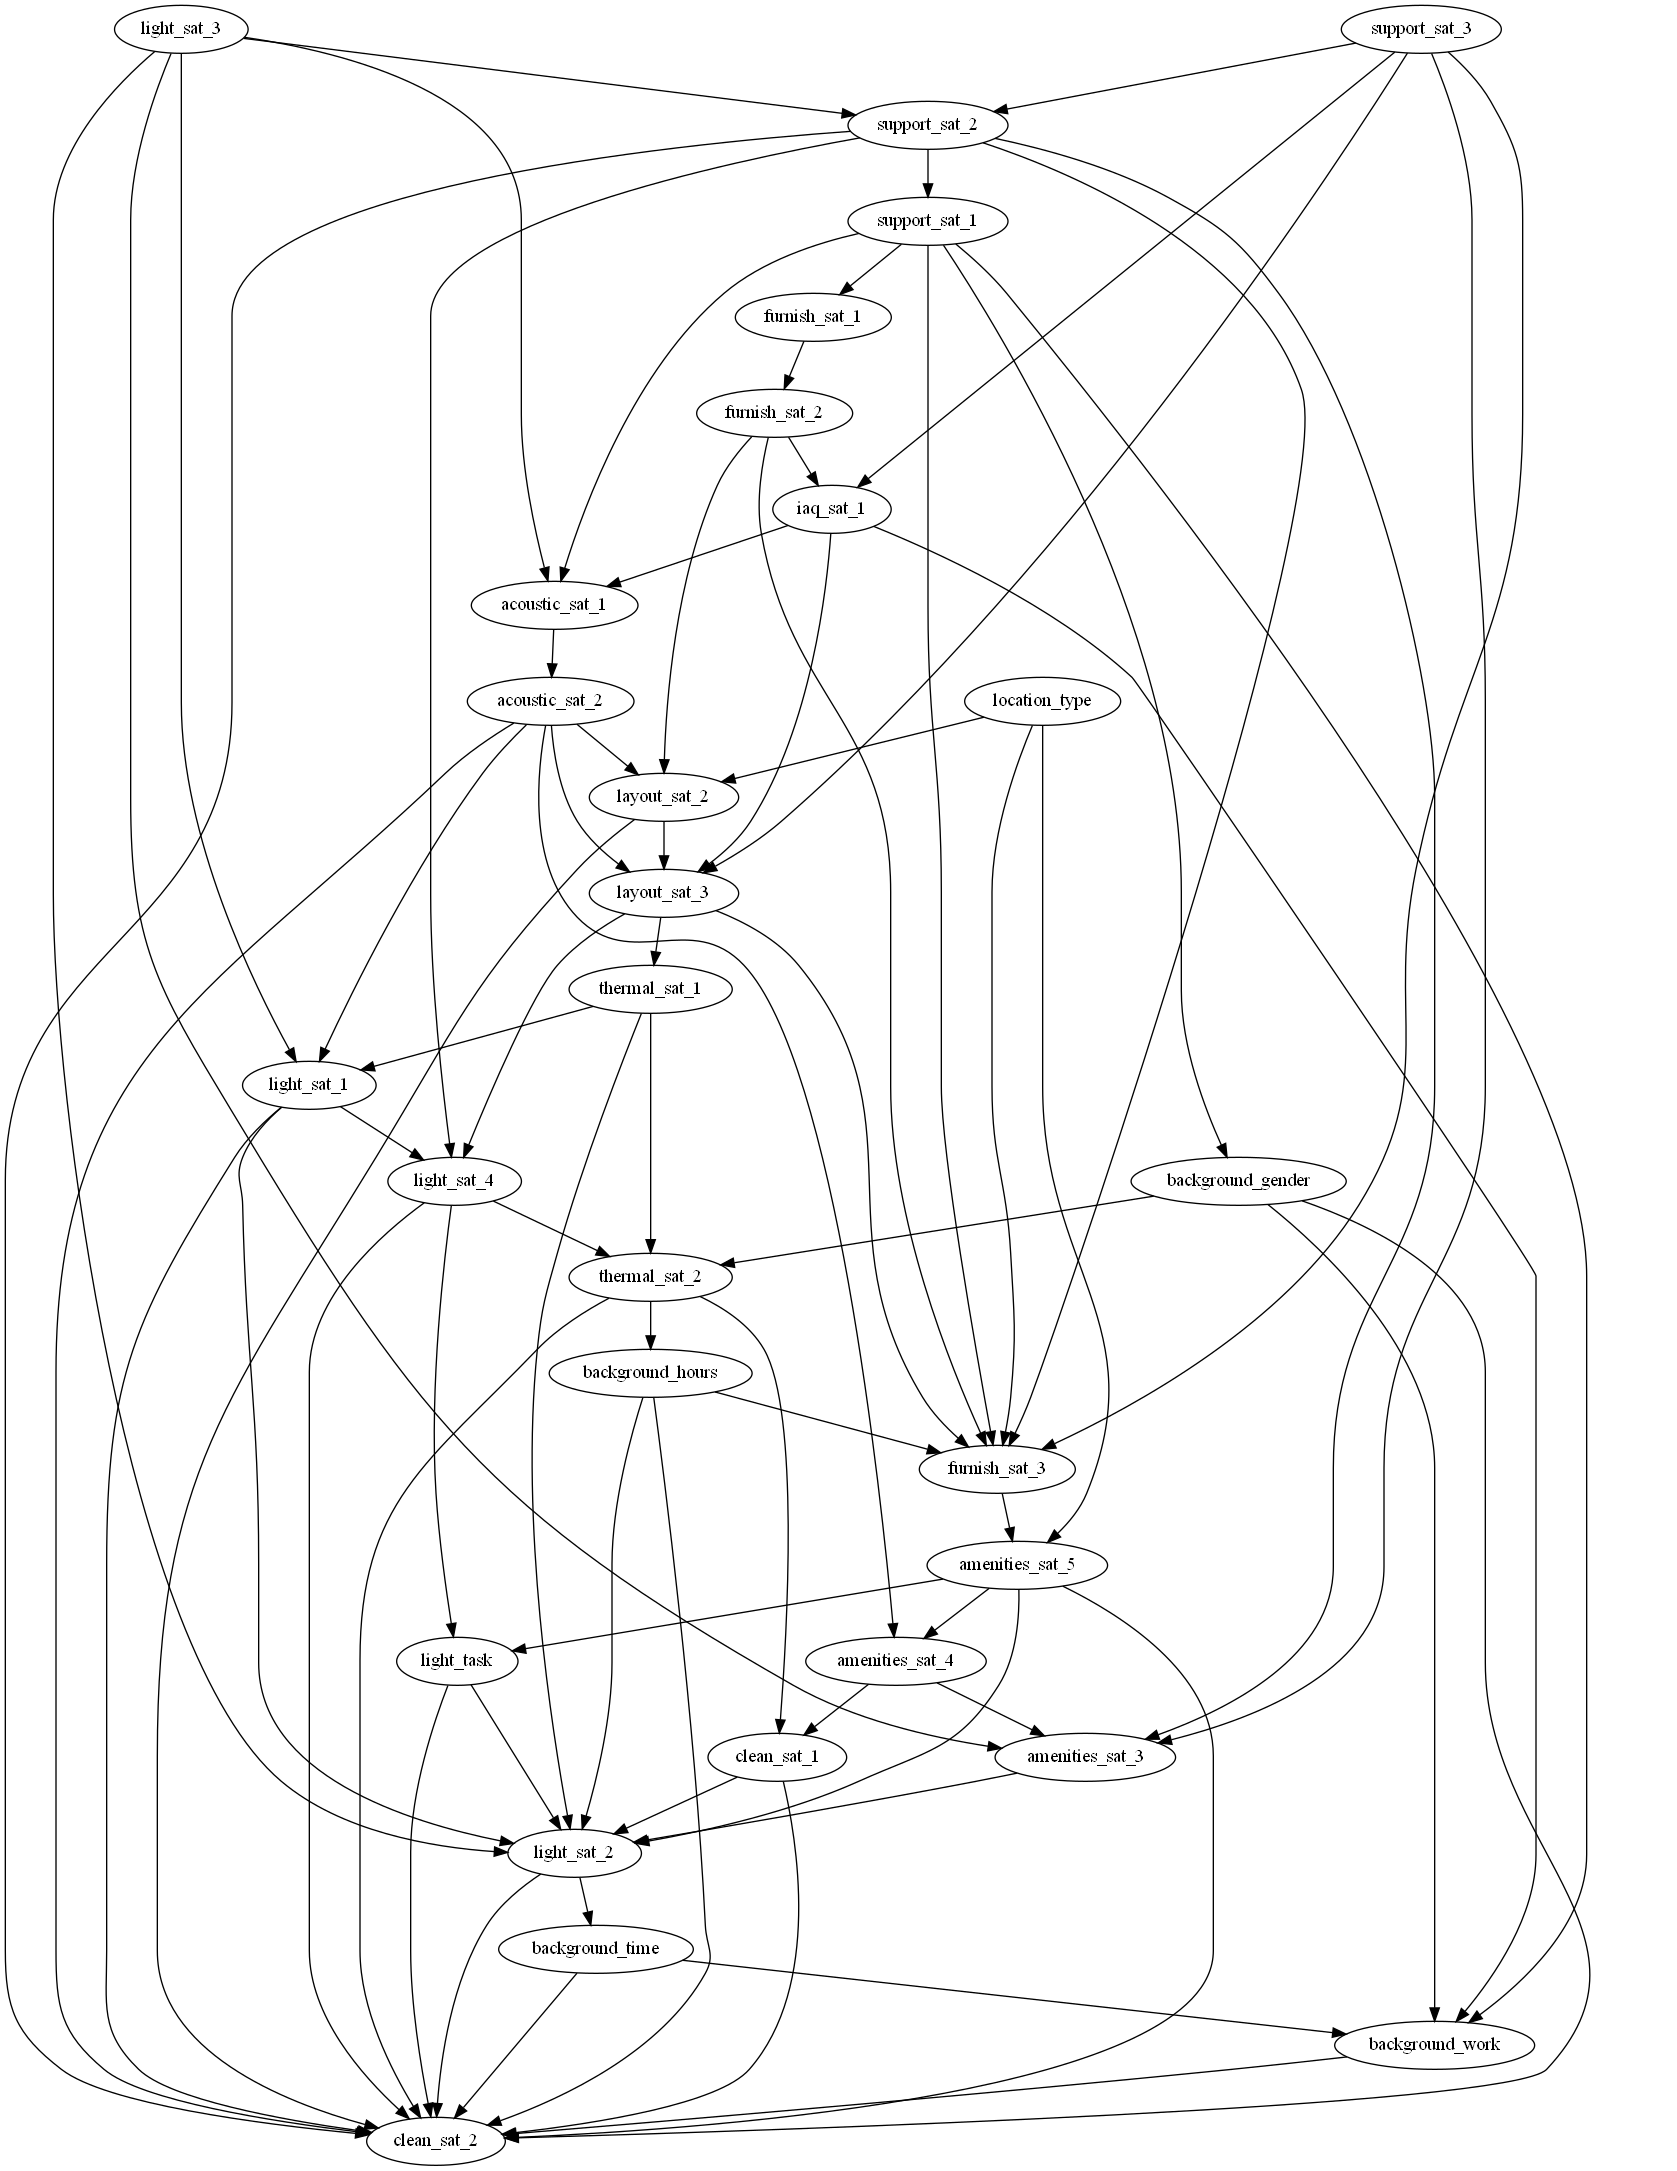

In [18]:
import pygraphviz as pgv
import cdt
import networkx as nx
from IPython.display import Image
cdt.SETTINGS.rpath = 'E:/Program Files/R/R-4.3.2/bin/Rscript' # path to your r executable

# cdt.SETTINGS.verbose = True
import networkx as nx
from cdt.causality.graph import GES, CCDr, CAM
from cdt.causality.graph.bnlearn import GS


# 构建骨架图/因果图
df_skeleton = new_data.copy()
# obj = CCDr()
obj = GES()
# obj = CGNN()
output = obj.predict(df_skeleton)    #No graph provided as an argument

A = nx.nx_agraph.to_agraph(output) 
# https://pygraphviz.github.io/documentation/stable/reference/agraph.html?highlight=draw#pygraphviz.AGraph.draw
# Optional prog=['neato'|'dot'|'twopi'|'circo'|'fdp'|'nop']
# A.layout(prog="dot", args="-Nshape=box -Efontsize=12")  # use dot
A.layout(prog='dot')  # use dot
A.draw("file.png")  # write previously positioned graph to PNG file
# # A.draw("file.ps", prog="circo")  # use circo to position, write PS file
# A.draw() 
Image('file.png')

In [11]:
A.nodes()

['background_time',
 'background_work',
 'clean_sat_2',
 'background_hours',
 'light_sat_2',
 'furnish_sat_3',
 'amenities_sat_5',
 'background_work_5_TEXT',
 'background_age',
 'background_gender',
 'thermal_sat_2',
 'clean_sat_1',
 'iaq_sat_1',
 'acoustic_sat_1',
 'layout_sat_3',
 'acoustic_sat_2',
 'thermal_sat_1',
 'light_sat_4',
 'layout_sat_1',
 'iaq_dis_level_1',
 'iaq_dis_level_2',
 'iaq_dis_level_3',
 'iaq_dis_iaq',
 'iaq_other_text',
 'light_sat_1',
 'thermal_dis_thermal',
 'thermal_dis_thermal_20_TEXT',
 'thermal_weather_hot',
 'thermal_weather_cold',
 'thermal_other_text',
 'light_task',
 'light_sat_3',
 'amenities_sat_3',
 'support_sat_2',
 'support_sat_1',
 'light_dis_light',
 'light_other_text',
 'layout_sat_2',
 'amenities_sat_4',
 'acoustic_dis_acousti',
 'acoustic_other_text',
 'furnish_sat_1',
 'furnish_sat_2',
 'furnish_dis_comfort',
 'furnish_other_text',
 'location_type',
 'location_type_6_TEXT',
 'layout_dis_space',
 'layout_dis_vispriv',
 'layout_dis_interact',


In [12]:
A.edges()

[('background_time', 'background_work'),
 ('background_time', 'clean_sat_2'),
 ('background_work', 'clean_sat_2'),
 ('background_hours', 'clean_sat_2'),
 ('background_hours', 'light_sat_2'),
 ('background_hours', 'furnish_sat_3'),
 ('light_sat_2', 'background_time'),
 ('light_sat_2', 'clean_sat_2'),
 ('furnish_sat_3', 'amenities_sat_5'),
 ('amenities_sat_5', 'clean_sat_2'),
 ('amenities_sat_5', 'light_sat_2'),
 ('amenities_sat_5', 'light_task'),
 ('amenities_sat_5', 'amenities_sat_4'),
 ('background_gender', 'background_work'),
 ('background_gender', 'clean_sat_2'),
 ('background_gender', 'thermal_sat_2'),
 ('thermal_sat_2', 'clean_sat_2'),
 ('thermal_sat_2', 'background_hours'),
 ('thermal_sat_2', 'clean_sat_1'),
 ('clean_sat_1', 'clean_sat_2'),
 ('clean_sat_1', 'light_sat_2'),
 ('iaq_sat_1', 'background_work'),
 ('iaq_sat_1', 'acoustic_sat_1'),
 ('iaq_sat_1', 'layout_sat_3'),
 ('acoustic_sat_1', 'acoustic_sat_2'),
 ('layout_sat_3', 'furnish_sat_3'),
 ('layout_sat_3', 'thermal_sat_1')

In [13]:
G = pgv.AGraph()
for n in A.nodes():
    G.add_node(n)
for e in A.edges():    
    G.add_edge(e[0],e[1])
G.string().replace("\n", " ").replace("\t", " ").replace("--", "->")

'strict graph "" {  background_time -> background_work;  background_time -> clean_sat_2;  background_work -> clean_sat_2;  background_hours -> clean_sat_2;  background_hours -> light_sat_2;  background_hours -> furnish_sat_3;  light_sat_2 -> background_time;  light_sat_2 -> clean_sat_2;  furnish_sat_3 -> amenities_sat_5;  amenities_sat_5 -> clean_sat_2;  amenities_sat_5 -> light_sat_2;  amenities_sat_5 -> light_task;  amenities_sat_5 -> amenities_sat_4;  background_work_5_TEXT;  background_age;  background_gender -> background_work;  background_gender -> clean_sat_2;  background_gender -> thermal_sat_2;  thermal_sat_2 -> clean_sat_2;  thermal_sat_2 -> background_hours;  thermal_sat_2 -> clean_sat_1;  clean_sat_1 -> clean_sat_2;  clean_sat_1 -> light_sat_2;  iaq_sat_1 -> background_work;  iaq_sat_1 -> acoustic_sat_1;  iaq_sat_1 -> layout_sat_3;  acoustic_sat_1 -> acoustic_sat_2;  layout_sat_3 -> furnish_sat_3;  layout_sat_3 -> thermal_sat_1;  layout_sat_3 -> light_sat_4;  layout_sat_3 -

In [ ]:
new_data.to_csv('validataion.csv')